In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pywt

import os
os.chdir("../../..")

from scripts.NEURON_Sim_Wrapper import Network

In [2]:
file_path = "./Datasets/Generated/Experiments/Sensory_Input_Experiments/3k_inh-exc_70con_2000ms_stim_input_all_amp02_1000ms_000059synweight_2syndelay.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)
    
t = data['t']
voltages = data['voltages']



# # Remove this
# # --- 1. Расширяем t до 5000 ---
# dt = t[1] - t[0]  # шаг (0.25)
# t_extended = np.arange(0, 5000 + dt, dt)

# # --- 2. Обрабатываем voltages ---
# new_voltages = {}

# for neuron_id, v in voltages.items():
#     v = np.array(v)
    
#     half_idx = len(v) // 2
#     last_half = v[half_idx:]  # последняя половина
    
#     # повторяем 8 раз
#     repeated = np.tile(last_half, 8)
    
#     # подгоняем под длину t_extended
#     if len(repeated) < len(t_extended):
#         # если вдруг не хватило — доклеим ещё
#         extra = np.tile(last_half, int(np.ceil((len(t_extended) - len(repeated)) / len(last_half))))
#         repeated = np.concatenate([repeated, extra])
    
#     new_voltages[neuron_id] = repeated[:len(t_extended)]

# t = t_extended
# voltages = new_voltages




sr = 0.00025Ц
real_time_ms = int(len(t)*sr*1000)

print(f"t: {len(t)} sampls ({real_time_ms} ms) ")               
print("neurons:", len(list(voltages.keys())))
print("voltages:", len(voltages["8980589"]))

t: 8001 sampls (2000 ms) 
neurons: 3016
voltages: 8001


# DN-VNC паттерны

| Поведение | Сегменты (Порядок активации) | Характер нейронного сигнала |
| :--- | :--- | :--- |
| **Forward Crawling** | $A8 \to A1 \to T3 \to T1$ | Ритмическая волна (Posterior $\to$ Anterior) |
| **Backward Crawling** | $T1 \to T3 \to A1 \to A8$ | Ритмическая волна (Anterior $\to$ Posterior) |
| **Turning (Поворот)** | $T1, T2, T3, A1$ | Билатеральная асимметрия ($L \neq R$) |
| **Hunching (Горб)** | Все сегменты одновременно | Синхронный мощный burst (вспышка) |
| **Head Sweep** | $SEZ, T1$ | Медленные осцилляции, попеременно $L \to R$ |


<div style="display: flex; justify-content: space-between; gap: 20px;">
  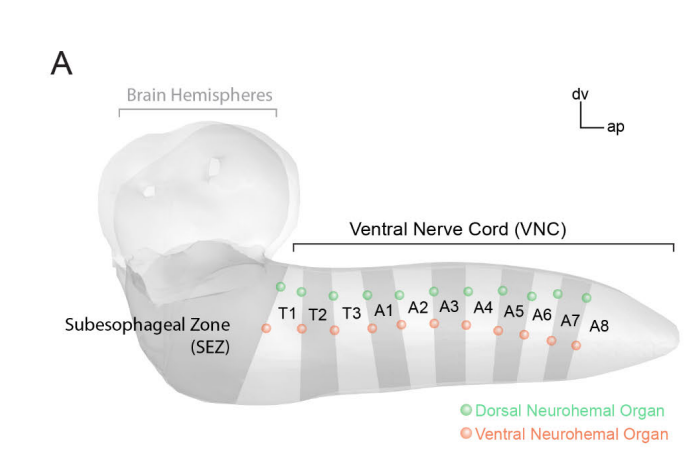
  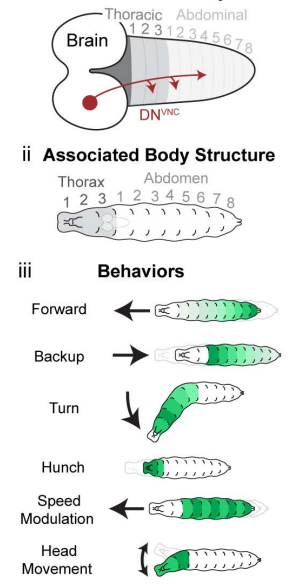
  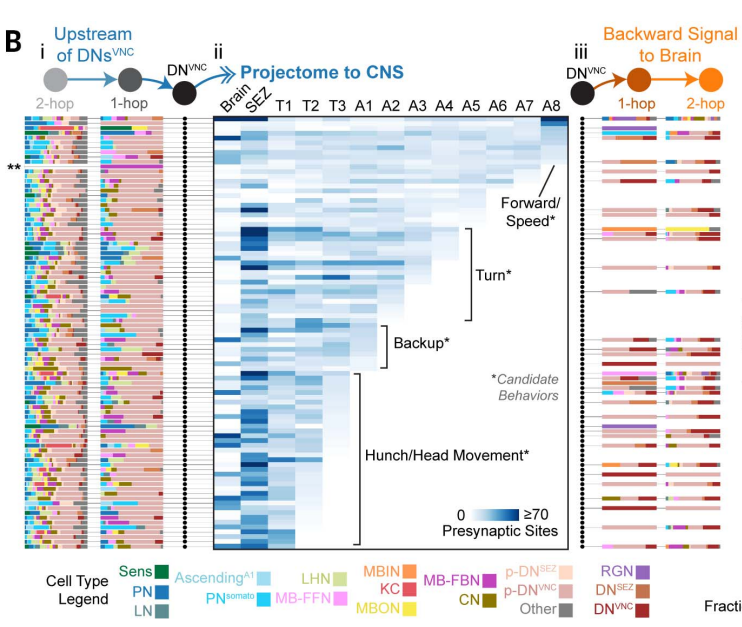
</div>

#### 1. Ползание вперёд (Forward crawling)
* **Физика:** Перистальтическая волна сокращений от хвоста к голове.
* **Активность:**
    * Последовательная активация: **A8 → A7 → ... → A1 → T1**.
    * Задержка между сегментами линейно масштабируется с периодом цикла.
    * *Важно:* В изолированной ЦНС волны в ~10 раз медленнее реальных.

#### 2. Ползание назад (Backward crawling)
* **Физика:** Волна сокращений от головы к хвосту.
* **Активность:**
    * Активация в порядке: **T1 → T2 → ... → A8** (инверсия прямого хода).
    * Паттерн генерируется самим VNC, мозг лишь инициирует его.

#### 3. Поворот (Turning)
* **Физика:** Асимметричное сокращение мышц передних сегментов (head sweeping) для выбора направления.
* **Активность:**
    * **Асимметрия $L/R$:** Нейроны одной стороны активнее другой в сегментах **T1–A1**.
    * Требует участия головного мозга и SOG. Одиночные всплески, а не ритм.

#### 4. Хантинг (Hunching)
* **Физика:** Защитное одновременное сокращение всего тела ("сжатие"). Нет поступательного движения.
* **Активность:**
    * **Синхронность:** Мощная одновременная вспышка во всех сегментах.
    * Отсутствует межсегментарная задержка (принципиальное отличие от ползания).

#### 5. Регуляция скорости (Speed modulation)
* **Механика:** Регулируется **частотой волн** (как часто они возникают), а не скоростью прохождения самой волны.
* **Активность:**
    * Интернейроны **PMSIs** ограничивают длительность burst.
    * При ускорении: сокращаются паузы между волнами, но структура самой волны сохраняется.